## Çok sınıflı sınıflandırma (Multiclass classification)

* Önceki görevde ikili (binary) bir sınıflandırma problemini çözdük.  
* Peki ya **çok sınıflı (multiclass) bir sınıflandırma problemi**?

🎯 Egzersizin Amaçları:
- Çok sınıflı bir sınıflandırma problemi için tasarlanmış bir Sinir Ağı (Neural Network) yazmak
- Bu modelin ne kadar kolay **overfit** olabileceğini gözlemlemek… !

## (1) Bir `Blobs` veri kümesi oluşturun

📚 Sklearn’deki **`make_blobs`** fonksiyonu [(dokümantasyona bakınız)](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_blobs.html) aşağıdakileri üretmenize olanak tanır:
- İstenilen sayıda veri örneği (`n_samples` parametresi)
- Her veri örneği için istenilen sayıda özellik (`n_features` parametresi)
- İstenilen sayıda sınıf/kategori (`centers` parametresi)
- Sınıflar arasındaki mesafe (`cluster_std` parametresi)

💡 Ayrıca, verinin **deterministik** olarak (aynı şekilde) üretilmesini ve tekrar edilebilir olmasını sağlayan `random_state` parametresi de vardır.


❓ Belgelere göre:

👽 Aşağıdakilerle bir ***blobs*** veri kümesi oluşturun:
- 1200 örnek
- Örnek başına 8 özellik
- 7 veri kategorisi
- Kategoriler arasındaki mesafe 8

🔮 1'e eşit bir `random_state` seçin.

📏 Şekli yazdırın ve `X` için (1200, 8) ve `y` için (1200,) ile eşleştiğini kontrol edin ❓

In [3]:
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=1200, 
                  n_features=8, 
                  centers=7, 
                  cluster_std=8.0, 
                  random_state=1)

print(f"X'in şekli: {X.shape}")
print(f"y'nin şekli: {y.shape}")

if X.shape == (1200, 8) and y.shape == (1200,):
    print("Başarılı! Şekiller beklenen değerlerle eşleşiyor.")
else:
    print("Bir hata var, şekiller eşleşmiyor.")

X'in şekli: (1200, 8)
y'nin şekli: (1200,)
Başarılı! Şekiller beklenen değerlerle eşleşiyor.


❓ _matplotlib_ kullanarak bu blob veri kümesinin iki (rastgele) boyutunun dağılım grafiğini çizin. Her nokta, ait olduğu kategoriye göre renklendirilmelidir. ❓

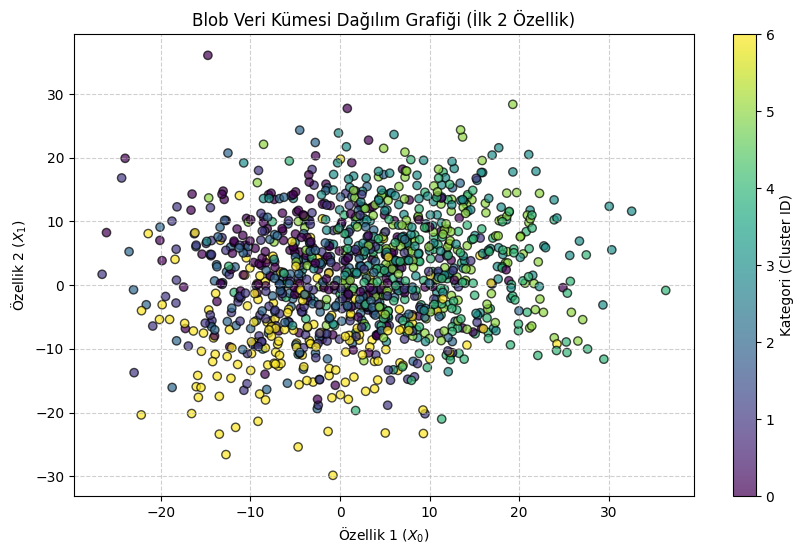

In [4]:
import matplotlib.pyplot as plt

# Grafik boyutunu ayarlayalım
plt.figure(figsize=(10, 6))

# Dağılım grafiğini (scatter plot) çizelim
# X[:, 0] -> 1. özellik (x ekseni)
# X[:, 1] -> 2. özellik (y ekseni)
# c=y -> Renklendirme kategorilere (y) göre yapılsın
# cmap='viridis' -> Renk paleti seçimi
scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolors='k', alpha=0.7)

# Renk çubuğu ekleyerek hangi rengin hangi kategori olduğunu görelim
plt.colorbar(scatter, label='Kategori (Cluster ID)')

# Başlık ve etiketler
plt.title("Blob Veri Kümesi Dağılım Grafiği (İlk 2 Özellik)")
plt.xlabel("Özellik 1 ($X_0$)")
plt.ylabel("Özellik 2 ($X_1$)")
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

❓ Diğer boyutlarda da aynı işlemi tekrarlayın. Veri noktalarının kolayca ayrılmadığını görsel olarak görebilirsiniz ❓

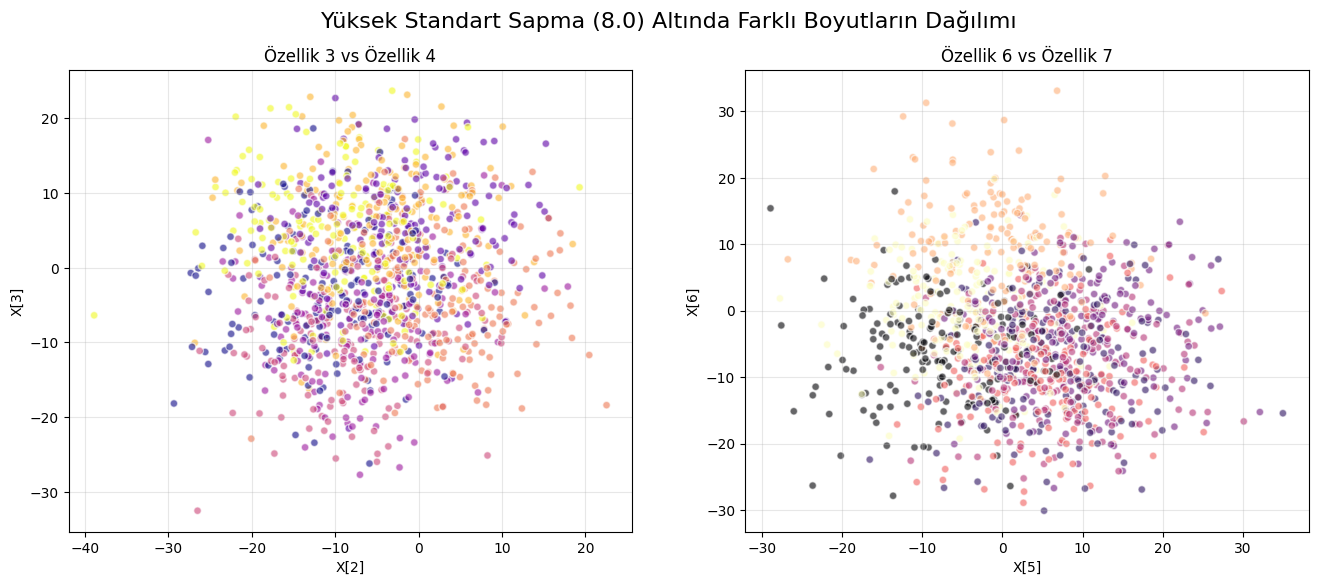

In [5]:
import matplotlib.pyplot as plt

# 1x2'lik bir grafik düzeni oluşturalım
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Senaryo 1: 3. ve 4. özellikler (İndeks 2 ve 3)
ax1.scatter(X[:, 2], X[:, 3], c=y, cmap='plasma', alpha=0.6, edgecolors='w', s=30)
ax1.set_title("Özellik 3 vs Özellik 4")
ax1.set_xlabel("X[2]")
ax1.set_ylabel("X[3]")
ax1.grid(True, alpha=0.3)

# Senaryo 2: 6. ve 7. özellikler (İndeks 5 ve 6)
ax2.scatter(X[:, 5], X[:, 6], c=y, cmap='magma', alpha=0.6, edgecolors='w', s=30)
ax2.set_title("Özellik 6 vs Özellik 7")
ax2.set_xlabel("X[5]")
ax2.set_ylabel("X[6]")
ax2.grid(True, alpha=0.3)

plt.suptitle("Yüksek Standart Sapma (8.0) Altında Farklı Boyutların Dağılımı", fontsize=16)
plt.show()

## (2) Çok sınıflı sınıflandırma probleminin hedefini kodlama

👉 Şu an için hedef `y`, giriş verisinin ait olduğu kategoriyi temsil eden **tamsayılar listesidir**. Şöyle görünür:  
`[3, 2, 2, 3, 0, 5, 1, 1, 0, 5, ...]`  
(bu örnekte 0’dan 6’ya kadar **7 kategori** vardır).

🧑🏻‍🏫 Ancak **Tensorflow/Keras’ta kategorik problemler için hedef/çıktı (`target/output`) aşağıdaki şekilde encode edilmelidir**:

```
[
[0, 0, 0, 1, 0, 0, 0], 
[0, 0, 1, 0, 0, 0, 0], 
[0, 0, 1, 0, 0, 0, 0], 
[1, 0, 0, 0, 0, 0, 0], 
[0, 0, 0, 0, 0, 1, 0], 
[0, 1, 0, 0, 0, 0, 0],
[0, 1, 0, 0, 0, 0, 0],
[1, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 1],
...
]
```


Burada:
- satır sayısı, **gözlem sayısına** eşittir  
- sütun sayısı, **farklı kategori sayısına** eşittir  

👉 Her sütun bir **kategoriyi** temsil eder.  

👉 Her satır bir **hedefi** temsil eder; `1` değeri, giriş verisinin ait olduğu kategoriyi gösterir.  

Bir satırı, olasılık vektörü olarak düşünebilirsiniz.

```
Örnek:
| Cat 0 | Cat 1 | Cat 2 | Cat 3 | Cat 4 | Cat 5 | Cat 6 |
|-------|-------|-------|-------|-------|-------|-------|
| 0     | 0     | 0     | 1     | 0     | 0     | 0     |

Bu, ilgili satırın %100 olasılıkla Cat 3’e ait olduğu anlamına gelir.
Cat 3
```


---

💡 `y`’yi kategorik hale dönüştürmek için **Tensorflow/Keras içindeki `to_categorical`** fonksiyonunu kullanın.

<details>
    <summary><i>Tensorflow/Keras’taki <code>to_categorical</code> ile Scikit-Learn’deki <code>OneHotEncoder</code> arasında bir benzerlik var mı?</i></summary>

Evet! **`to_categorical`**, Sklearn’deki `OneHotEncoder` gibi çalışır;  
ancak burada bir **kategorik feature** değil, **kategorik target (hedef)** encode edilir.

</details>

---

❓ **Kategorik hedefin kodlanması**:  `y` yazdırın, ardından *to_categorical* işlevini *`y`* üzerinde uygulayın ve *y'nin kategorize edilmiş halini* `y_cat` adlı bir değişkene kaydedin. ❓

In [6]:
from tensorflow.keras.utils import to_categorical

# Orijinal y'yi görelim
print(f"Orijinal y'nin ilk 5 örneği: {y[:5]}")

# y'yi kategorik hale getirme
y_cat = to_categorical(y, num_classes=7)

# Dönüştürülmüş y_cat'i görelim
print(f"y_cat'in ilk 5 örneği:\n{y_cat[:5]}")
print(f"y_cat'in şekli: {y_cat.shape}") # (1200, 7) olmalı

Orijinal y'nin ilk 5 örneği: [2 2 5 1 2]
y_cat'in ilk 5 örneği:
[[0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0.]
 [0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0.]]
y_cat'in şekli: (1200, 7)


## (3) Çok Sınıflı Sınıflandırma Görevi için Sinir Ağı

❓ **Hold-out yöntemi**: Veri kümesi $X$ ve $y_{cat}$ 'i _train_ ve _test_ kümelerine ayırın (boyut: 70/30%)

Not: Değişkenleri `X_train`, `X_test`, `y_train` ve `y_test` olarak adlandırın ❓

In [7]:
from sklearn.model_selection import train_test_split

# X ve y_cat değişkenlerini kullanarak ayırma işlemi
X_train, X_test, y_train, y_test = train_test_split(X, y_cat, test_size=0.30, random_state=1)

print(f"Eğitim seti boyutu: {X_train.shape}")
print(f"Test seti boyutu: {X_test.shape}")

Eğitim seti boyutu: (840, 8)
Test seti boyutu: (360, 8)


Derin Öğrenmede, herhangi bir Makine Öğrenimi algoritmasında olduğu gibi, sayısal özellikleriniz ölçeklendirilmelidir.

❓ **Ölçeklendirme**: Eğitim kümesine bir Sklearn [`StandardScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) uydurun ve hem eğitim kümenizi hem de test kümenizi dönüştürün ❓

In [8]:
from sklearn.preprocessing import StandardScaler

# Scaler nesnesini oluşturma
scaler = StandardScaler()

# SADECE train setine fit ediyoruz (bilgi sızıntısını önlemek için)
scaler.fit(X_train)

# Hem train hem test setini dönüştürüyoruz
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)


❓ **Modeli başlatma**: Aşağıdaki işlevi tamamlayarak aşağıdaki özelliklere sahip bir model oluşturun/başlatın:
- İlk katman:
   - 50 nöron
   - `relu` aktivasyonu
   - Doğru giriş boyutu
- Çıkış katmanı:
   - Çok sınıflı sınıflandırma görevi için tasarlanmış
   - Her sınıfa ait olma olasılıklarını çıktı olarak veren ❓

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
def initialize_model():

    #############################
    #  1 - Model mimarisi   #
    #############################

    # 1. Sequential (Ardışık) modeli başlatıyoruz
    model = Sequential()
    model.add(Input(shape=(8,)))
    # 2. İlk Gizli Katman (First Hidden Layer)
    # 50 nöron, ReLU aktivasyonu ve 8 giriş özelliği (X'in sütun sayısı)
    model.add(Dense(50, activation='relu', input_dim=8))
    
    # 3. Çıkış Katmanı (Output Layer)
    # 7 sınıfımız olduğu için 7 nöron
    # Olasılık çıktıları için 'softmax' aktivasyonu şarttır
    model.add(Dense(7, activation='softmax'))

    #############################
    #  2 - Optimizasyon Yöntemi #
    #############################
    model.compile(loss='categorical_crossentropy', # binary_crossentropy'den farklıdır çünkü birden fazla sınıfımız vardır
                  optimizer='adam',
                  metrics=['accuracy'])

    return model


model = initialize_model()

❓  Modelde kaç parametre (diğer adıyla ağırlık) vardır? ❓

In [13]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 50)             │           450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           357 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 807 (3.15 KB)

 Trainable params: 807 (3.15 KB)

 Non-trainable params: 0 (0.00 B)

❓ **Modeli uydurma**: Modelinizi 50 dönemlik tren verilerine uydurun ve geçmişi çizin ❓

Epoch 1/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.1643 - loss: 1.9571 - val_accuracy: 0.2639 - val_loss: 1.8420
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3238 - loss: 1.7275 - val_accuracy: 0.3833 - val_loss: 1.6552
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4595 - loss: 1.5457 - val_accuracy: 0.4889 - val_loss: 1.5033
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5631 - loss: 1.3942 - val_accuracy: 0.5833 - val_loss: 1.3730
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6202 - loss: 1.2665 - val_accuracy: 0.6222 - val_loss: 1.2680
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6607 - loss: 1.1613 - val_accuracy: 0.6556 - val_loss: 1.1806
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6905 - loss: 1.0756 - val_accuracy: 0.6556 - val_loss: 1.1122
Epoch 8/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7012 - loss: 1.0054 - val_accuracy: 0.6750 - val_loss:

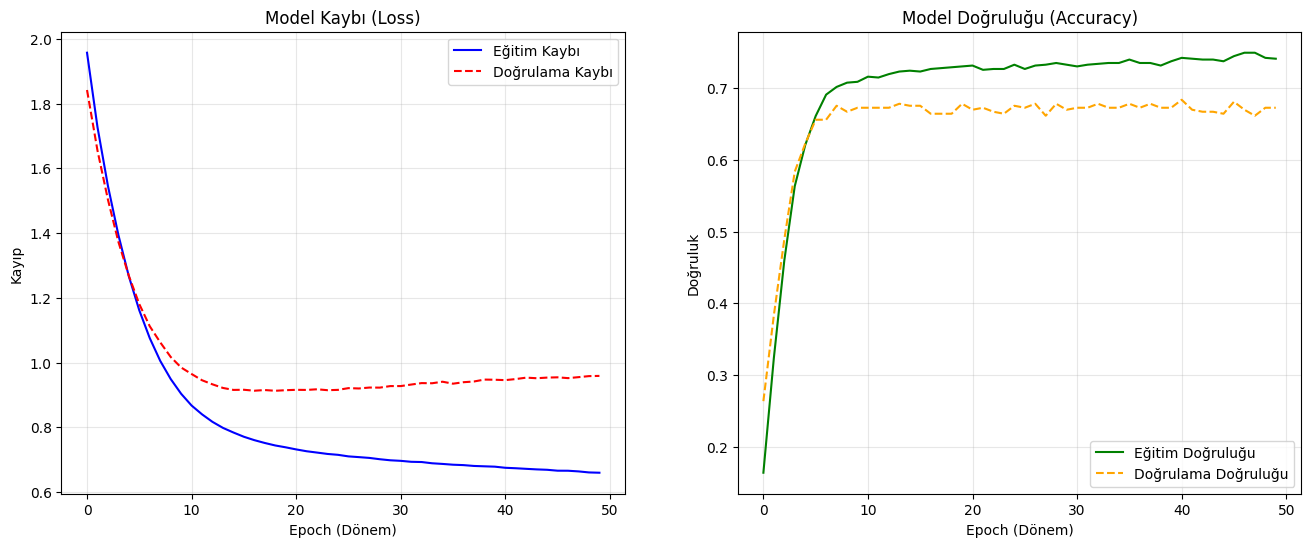

In [14]:
import matplotlib.pyplot as plt

# 1. Modeli Eğitme (Fitting)
# epochs=50 -> Veri kümesi üzerinden 50 tam geçiş yapılacak
# batch_size=32 -> Her adımda 32 örnek işlenecek
# validation_data -> Her dönem sonunda test seti üzerinde performans ölçülecek
history = model.fit(X_train, y_train, 
                    validation_data=(X_test, y_test), 
                    epochs=50, 
                    batch_size=32, 
                    verbose=1)

# 2. Geçmişi (History) Çizme
def plot_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # --- Kayıp (Loss) Grafiği ---
    ax1.plot(history.history['loss'], label='Eğitim Kaybı', color='blue')
    ax1.plot(history.history['val_loss'], label='Doğrulama Kaybı', color='red', linestyle='--')
    ax1.set_title('Model Kaybı (Loss)')
    ax1.set_xlabel('Epoch (Dönem)')
    ax1.set_ylabel('Kayıp')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # --- Doğruluk (Accuracy) Grafiği ---
    ax2.plot(history.history['accuracy'], label='Eğitim Doğruluğu', color='green')
    ax2.plot(history.history['val_accuracy'], label='Doğrulama Doğruluğu', color='orange', linestyle='--')
    ax2.set_title('Model Doğruluğu (Accuracy)')
    ax2.set_xlabel('Epoch (Dönem)')
    ax2.set_ylabel('Doğruluk')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.show()

# Fonksiyonu çağırarak grafikleri gösterelim
plot_history(history)

❓ **Değerlendirme**:  Modelinizi test setinde değerlendirin ve doğruluğu yazdırın ❓

In [15]:
# Modeli test seti üzerinde değerlendirme
results = model.evaluate(X_test, y_test, verbose=0)

# Sonuçları yazdırma
# results[0] -> Loss (Kayıp)
# results[1] -> Accuracy (Doğruluk)
print(f"Test Seti Kaybı: {results[0]:.4f}")
print(f"Test Seti Doğruluğu: %{results[1]*100:.22f}")

Test Seti Kaybı: 0.9589
Test Seti Doğruluğu: %67.2222197055816650390625


❓ 🤔 Bu iyi bir puan mı? Bunu bir tür karşılaştırma değeriyle karşılaştırmalısınız. Bu durumda, rastgele bir tahminle ne kadar puan elde edilebilir? Bu temel puanı `accuracy_baseline` değişkeninde saklayın. ❓

(Bunun için kod yazmanıza gerek yok, sadece veri setimizin nasıl oluşturulduğunu düşünün.)

In [16]:
accuracy_baseline = 0.1428

🧪 **Kodunu Test Et**

In [17]:
from nbresult import ChallengeResult
result = ChallengeResult('baseline',
                         accuracy=accuracy_baseline)
result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/aybukealtuntas/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/aybukealtuntas/S18D2-S-Data-multiclass-classification/tests
plugins: dash-4.0.0, anyio-4.8.0, typeguard-4.4.2
collecting ... collected 1 item

test_baseline.py::TestBaseline::test_accuracy PASSED                     [100%]

============================== 1 passed in 0.01s ===============================


💯 You can commit your code:

git add tests/baseline.pickle

git commit -m 'Completed baseline step'

git push origin master



❗ 👀 Bekle ... Kayıp grafiğine daha yakından bakarsan, 50 dönemden sonra da kayıp hala azalmaya devam ediyor gibi görünüyor. Neden bu kadar erken durduruyorsun ❓❗

❓ Modeli yeniden başlatıp bu sefer 1000 dönemle tekrar çalıştıralım ve geçmişi tekrar grafiğe çizelim. ❓

In [19]:
history2 = model.fit(X_train, y_train, 
                    validation_data=(X_test, y_test), 
                    epochs=1000, 
                    batch_size=32, 
                    verbose=1)

Epoch 1/1000
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7679 - loss: 0.5953 - val_accuracy: 0.6722 - val_loss: 1.0305
Epoch 2/1000
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7726 - loss: 0.5939 - val_accuracy: 0.6750 - val_loss: 1.0376
Epoch 3/1000
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7679 - loss: 0.5929 - val_accuracy: 0.6722 - val_loss: 1.0343
Epoch 4/1000
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7738 - loss: 0.5936 - val_accuracy: 0.6722 - val_loss: 1.0364
Epoch 5/1000
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7738 - loss: 0.5904 - val_accuracy: 0.6639 - val_loss: 1.0410
Epoch 6/1000
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7750 - loss: 0.5893 - val_accuracy: 0.6611 - val_loss: 1.0442
Epoch 7/1000
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7750 - loss: 0.5890 - val_accuracy: 0.6667 - val_loss: 1.0396
Epoch 8/1000
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7702 - loss: 0.5878 - val_accuracy: 0.

❓ **Bir modeli daha uzun süre eğitirken...** ❓
- Yeni kayıp hakkında ne söyleyebilirsiniz?
- Modelinizi test setinde bir kez daha değerlendirin ve doğruluğu yazdırın.

In [20]:
# Modeli test seti üzerinde değerlendirme
results = model.evaluate(X_test, y_test, verbose=0)

# Sonuçları yazdırma
# results[0] -> Loss (Kayıp)
# results[1] -> Accuracy (Doğruluk)
print(f"Test Seti Kaybı: {results[0]:.4f}")
print(f"Test Seti Doğruluğu: %{results[1]*100:.22f}")

Test Seti Kaybı: 2.4887
Test Seti Doğruluğu: %58.3333313465118408203125


* 😁 Tren setinde hesaplanan kayıp, 50 epok ile karşılaştırıldığında 1000 epok ile daha küçük görünüyor.
* 😟 Anc ak test setindeki doğruluk, 50 epok ile karşılaştırıldığında 1000 epok ile daha kötü...

❓ Bu fenomene ne denir? ❓

>Yüksek epok sayısı (1000), modelin varyansını (variance) artırarak eğitim setindeki hata payını düşürse de, test setindeki hata payının artmasına yol açmıştır. Bu, modelin karmaşıklığının veri setindeki gürültüye göre çok fazla olduğunun kanıtıdır.

---

🤔 Bunun olmasını önlemek için ne yapmalıyız? 

<details>
    <summary><i>Olası seçenekler</i></summary>
    

⚠️ Sinir ağlarında aşırı uyumun olmasını önlemek için, örneğin şunları yapabiliriz:
1. Sinir ağının gürültülü veri noktalarından çok fazla öğrenmesini önlemek için ***makul sayıda dönem*** seçin
2. ***Erken Durdurma*** kriteri, yani _.fit()_ 📆 cf. ***Derin Öğrenme > Optimize Ediciler, Kayıp, Uydurma***

</details>    

---


❓ Test kaybının pratikte ne zaman tekrar artmaya başladığını görsel olarak kontrol edelim.  Aşağıdaki komutu çalıştırın ve geçmişi çizin❓

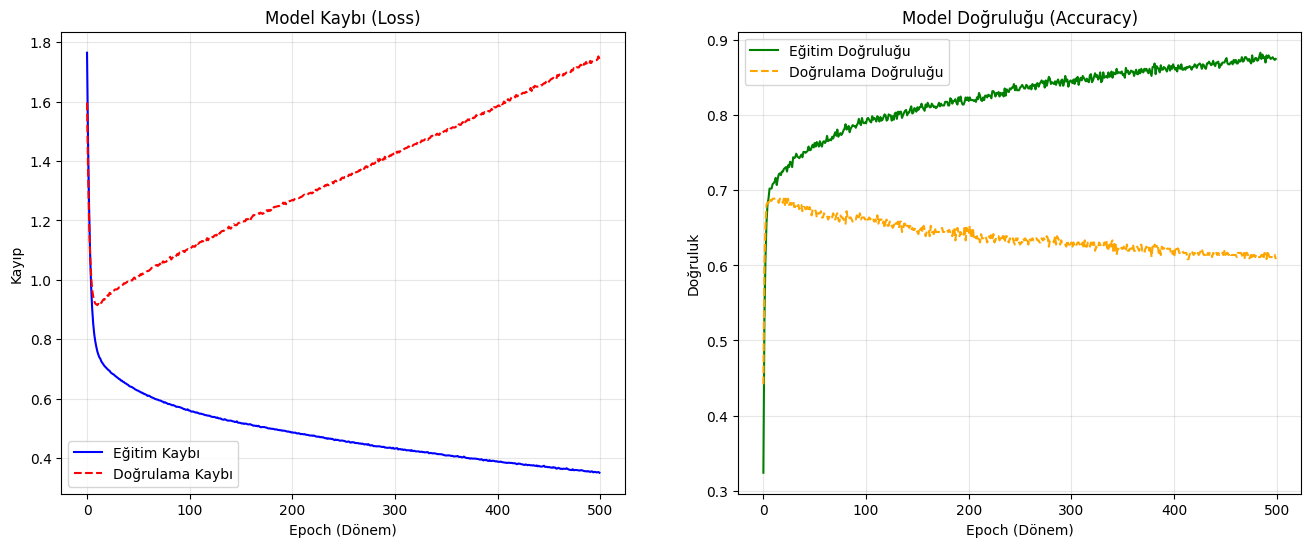

In [21]:
model = initialize_model()

history = model.fit(X_train,
                    y_train,
                    validation_data=(X_test, y_test),
                    epochs=500,
                    batch_size=16,
                    verbose=0)
plot_history(history)

😱 Ama durun... test setini kullanırsak hile yapmış olmaz mıyız? Evet, oluruz. Ama yine sabırlı olun. ***Derin Öğrenme - Optimize Ediciler, Kayıp, Uydurma*** bölümünde, bunu önlemek için ***Doğrulama Seti*** adını verdiğimiz şeyi kullanacağız!

🧘🏻‍♀️ Şimdilik, sonraki sorulara geçelim!

❓ **Ağı değerlendirme**: <span style="color:blue">eğitim seti</span> ve <span style="color:orange">test seti</span> üzerindeki kayıp ve doğruluk değerlerini grafik olarak gösterin. Bu konuda ne söyleyebilirsiniz? ❓ 

In [23]:
def plot_loss_accuracy(history):
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Test'], loc='best')
    plt.show()

    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Test'], loc='best')
    plt.show()

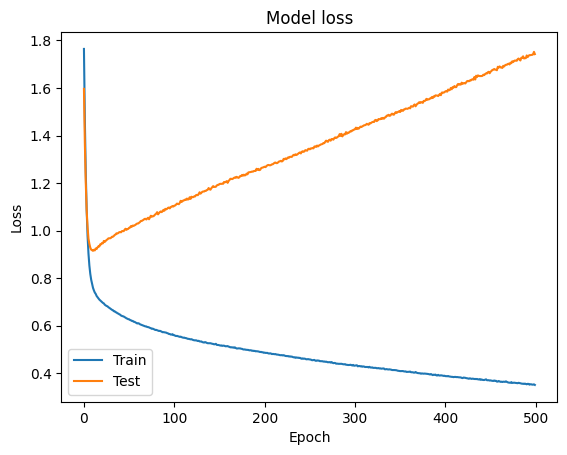

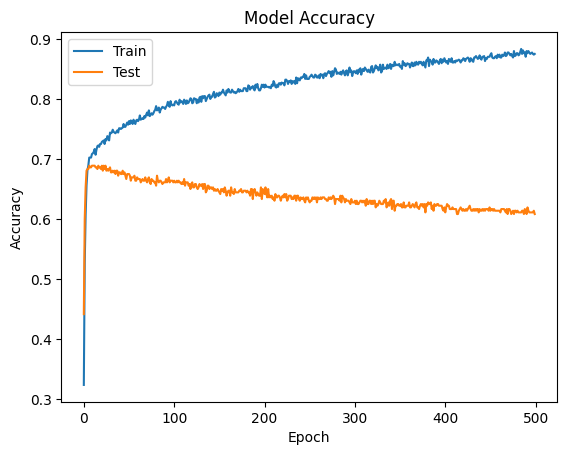

In [24]:
plot_loss_accuracy(history)

🤔 Derin Öğrenme modelimiz neden bu kadar kolay aşırı uyum sağlıyor?

😳 Düşünün, sinir ağımız sadece 8 özellik içeren bir veri kümesinden basit bir sınıflandırma görevi için ~800 parametre öğrenmek zorunda! Üstelik, uyum sağlamak için toplamda sadece ~800 veri noktamız var! Model, eğitim kümesindeki her noktanın tam sınıfını neredeyse “öğrenebilir”. 

Buna karşılık, basit bir Lojistik Regresyon, bu blob veri kümesinin kalıplarını yakalamak için sadece 9 parametreyi öğrenmek zorunda kalırdı! 

😏 Derin öğrenme etkileyici bir kavramdır, ancak basit makine öğrenimi görevleri için açıkça aşırı ve gereksiz bir seçenek olabilir!

⭐️ Aşağıdakiler için son derece yararlı olacaktır:
- 📸 Görüntü işleme
- 💹 Zaman serileri
- 🗣 Doğal dil işleme

---

🏁 Tebrikler!

💾 Not defterinizi `git add/commit/push` yapmayı unutmayın...

🚀 ... ve bir sonraki göreve geçin!